# Homework 2

### <p style="text-align: right;"> &#9989; Joseph Maleckas</p>
### <p style="text-align: right;"> &#9989; JosephM16</p>

## Goals for this homework assignment
By the end of this assignment, you should be able to:
* Define custom classes and show they are implemented correctly through tests.
* Implement agent based models and observe emergent phenomena.
* Use Pandas and NetworkX to create, analyze, and visualize graphs.
* Read documentation to learn about new code.
* Read and understand provided code.

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

There are **80 points** possible on this assignment. Point values for each part are included in the section headers and question prompts.

**This assignment is due on Wednesday, March 18th at 11:59pm ET.** It should be uploaded into the "Homework Assignments" submission folder for Homework #2.  Submission instructions can be found at the end of the notebook.

<a id="toc"></a>

## Table of contents

1. [Part 1: Git and CLI](#git) (8 points)

2. [Part 2: Agent based modeling](#abm) (42 points)

3. [Part 3: Graph theory](#graph) (30 points)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from IPython.display import display, clear_output

---
[Back to ToC](#toc)
<a id="git"></a>
# Part 1: Add to your Git repository to track your progress on your assignment (8 points)

For this assignment, you're going to add it to the `cmse202-s26-turnin` repository you created in class so that you can track your progress on the assignment and preserve the final version that you turn in. In order to do this you need to

**&#9989; Do the following**:

1. Navigate to your `cmse202-s26-turnin` repository and create a new directory called `hw-02`.
2. Move this notebook into that **new directory** in your repository, then **add it and commit it to your repository**.
3. Finally, to test that everything is working, "git push" the file so that it ends up in your GitHub repository.

**Important**: Double check you've added your Professor and your TA as collaborators to your "turnin" repository (you should have done this in the previous homework assignment).

**Also important**: Make sure that the version of this notebook that you are working on is the same one that you just added to your repository! If you are working on a different copy of the notebook, **none of your changes will be tracked**!

If everything went as intended, the file should now show up on your GitHub account in the "`cmse202-s26-turnin`" repository inside the `hw-02` directory that you just created.  Periodically, **you'll be asked to commit your changes to the repository and push them to the remote GitHub location**. Of course, you can always commit your changes more often than that, if you wish.  It can be good to get into a habit of committing your changes any time you make a significant modification, or when you stop working on the project for a bit.

&#9989; **1.1 Do this**: Before you move on, put the command that your instructor should run to clone your repository in the markdown cell below.

``` bash
# git clone https://github.com/JosephM16/CMSE202-f25-turnin.git
```

**You MUST commit and push your notebook multiple times during this assignment.**

---
[Back to ToC](#toc)
<a id="abm"></a>

# Part 2: Build an Agent Based Model for the predator-prey system (42 points)

<img src="https://www.engineered-mind.com/content/images/2022/10/Lotka-Volterra-copy.png" width=400px align="center" alt="Image credit: https://www.engineered-mind.com/">

For this problem, you will making a predator-prey model inspired by [Lotka-Volterra Equations](https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations).  You may remember them from when you took CMSE 201 as a system well represented with a compartmental model, and they look like this:

$$\frac{dx}{dt} = \alpha x - \beta xy$$
$$\frac{dy}{dt} = -\gamma y + \delta xy$$

Here, $x$ represents the prey population, and $y$ represents the predator population; These are the two *compartments* of this model.  In this system, the prey population grows at a rate proportional to its size ($\alpha x$), but is also reduced by interactions with the predators ($-\beta xy$).  The predator population, on the other hand, decreases at a rate proportional to its size ($-\gamma y$), but is increased by interactions with the prey ($\delta xy$).

In this problem, instead of solving the differential equations (instead of interpreting this as two compartments), we will build an **Agent Based Model** to approximate the same system.  We will provide some code to help you get started, but you will have to do some coding yourself to complete the code.

&#9989;  **Question 2.1 (9 points)** First we will make an `Animal` class to serve as our agents in the model.  This will serve as the base class for the `Predator` and `Prey` classes that we will create later.

Make the following modifications to complete the class:
1. (2 points) Change the `__init__` function to give the `Animal` class an attribute called `loc`.  This will store the location of the Animal during the simulation.  The `loc` attribute should be a list with two entries, the x coordinate (given by the `pos_x` input) as the first element in the list and the y coordinate (given by the `pos_y` input) as the second element in the list. 
2. (2 points) The `__init__` function should also give the `Animal` class an attribute called `rgb`.  This will store a color value in RGB format, which will come in handy later when we visualize the simulation.  For right now, make this attribute a list of three elements, all equal to 0.
3. (1 point) The `move` function should set the `loc` attribute to a new position based on the inputs `pos_x` and `pos_y`.
4. (2 points) The `get_neighbor_list` function should find the four direct neighbors of the Animal's location coordinates: one coordinate above, one coordinate below, one coordinate to the right, and one coordinate to the left.  These coordinates should be given as a list.  Ultimately, the function should return a list of the four neighboring coordinates, so you will end up with a list of lists. (So, for example, if the coordinates of the Animal's location was [4,2], the neighbor list to be returned would be [[3,2], [5,2], [4,3], [4,1]].  They can be in any order.)
5. (2 points) To practice good coding habits, add [docstrings](https://www.geeksforgeeks.org/python/python-docstrings/) to the functions.  At a minimum, the docstrings should contain a brief description of what the function does, as well as indicate what the inputs are (if any) and what the function returns (if anything).  A docstring for the whole class has been added for you.

In [6]:
# starting code with stub functions
class Animal():
    
    def __init__(self, pos_x, pos_y):
        
        self.loc = [pos_x, pos_y]
        self.rgb = [0, 0, 0]

    def move(self, pos_x, pos_y):
        
        self.loc = [pos_x, pos_y]

    def get_neighbor_list(self):
        
        x, y = self.loc
        
        return [
            [x + 1, y],
            [x - 1, y],
            [x, y + 1],
            [x, y - 1]
        ]

In order to test your code, run the cell below.  Note that the `assert` command is used here.  This can be very handy in code testing and code debugging.  If all is correct with your `Animal` class, the cell with run successfully.  If there is an error, the code will return an error.  Continue to revise your `Animal` class until there are no errors, and the docstrings print as you expect.

In [7]:
# DO NOT CHANGE THIS CELL
# USE THIS CELL TO TEST YOUR ANIMAL CLASS DEFINITION
test_animal = Animal(1,1)
assert test_animal.loc == [1, 1], "The location is not stored correctly!"
assert test_animal.rgb == [0, 0, 0], "The color is not set correctly!"
test_animal.move(5,6)
assert test_animal.loc == [5,6], "The move() function is not defined correctly!"
assert sorted(test_animal.get_neighbor_list()) == sorted([[6,6],[4,6],[5,7],[5,5]]), "The get_neighbor_list() function is not defined correctly!"
help(test_animal)

Help on Animal in module __main__ object:

class Animal(builtins.object)
 |  Animal(pos_x, pos_y)
 |
 |  Methods defined here:
 |
 |  __init__(self, pos_x, pos_y)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  get_neighbor_list(self)
 |
 |  move(self, pos_x, pos_y)
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object



&#9989;  **Question 2.2 (8 points)** Great! Now that we have our `Animal` class, it's time for us to make the `Predator` and `Prey` classes.  Let's start with the `Prey` class:
1. (2 points) Make a new class named `Prey`.  Make sure that it inherits from the `Animal` class!
2. (2 points) Within the `__init__` function, call the original `Animal.__init__` function to set the location of the `Prey` class.  (Be sure to include any necessary input arguments that you might need!)
3. (1 point) Also in the `__init__` function, overwrite the RGB value to a new color specific to the `Prey` class.  You can choose any color you want - in the example, we chose blue.
4. (1 point) Make a function called `get_type`.  This function should just return the string "Prey".
5. (2 points) Once again, add docstrings to the class.

In [8]:
# Put your Prey class definition here!
class Prey(Animal):
    
    def __init__(self, pos_x, pos_y):
        super().__init__(pos_x, pos_y)  # call Animal constructor
        self.rgb = [0, 0, 1]  # blue color

    def get_type(self):
        
        return "Prey"

Once again, use the cell below to check your work and verify your docstrings are working!

In [9]:
# DO NOT CHANGE THIS CELL
# USE THIS CELL TO TEST YOUR PREY CLASS DEFINITION
test_prey = Prey(1,1)
assert isinstance(test_prey,Animal), "Prey does not inherit from Animal class!"
assert test_prey.loc == [1,1], "Prey location is not set correctly!"
assert test_prey.get_type() == "Prey", "The get_type function is not defined correctly!"
help(test_prey)

Help on Prey in module __main__ object:

class Prey(Animal)
 |  Prey(pos_x, pos_y)
 |
 |  Method resolution order:
 |      Prey
 |      Animal
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, pos_x, pos_y)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  get_type(self)
 |
 |  ----------------------------------------------------------------------
 |  Methods inherited from Animal:
 |
 |  get_neighbor_list(self)
 |
 |  move(self, pos_x, pos_y)
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from Animal:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object



&#9989;  **Question 2.3 (6 points)** Finally, it's time for us to make the `Predator` class:
1. (1 point) Make a new class named `Predator`.  Once again, make sure that it inherits from the `Animal` class!
2. (1 point) Within the `__init__` function, call the original `Animal.__init__` function to set the location of the `Predator` class.
3. (1 point) Also in the `__init__` function, overwrite the RGB value to a new color specific to the `Predator` class.  You can choose any color you want, but *make sure it is different from the color of the `Prey` class*!  In our example, we chose red.
4. (1 point) Also in the `__init__` function, give the Predator an `age` attribute and make the starting value 0.
5. (1 point) Make a function called `get_type`.  This function should just return the string "Predator".
6. (1 point) Add docstrings!

In [10]:
# Define your Predator class here!
class Predator(Animal):
    
    def __init__(self, pos_x, pos_y):
        super().__init__(pos_x, pos_y)  # call Animal constructor
        self.rgb = [1, 0, 0]  # red color (different from Prey)
        self.age = 0

    def get_type(self):
        return "Predator"

Now, let's make sure to test the `Predator` class!

In [11]:
# DO NOT CHANGE THIS CELL
# USE THIS CELL TO TEST YOUR PREDATOR CLASS DEFINITION
test_predator = Predator(6,7)
assert isinstance(test_predator,Animal), "Predator does not inherit from Animal class!"
assert test_predator.loc == [6,7], "Predator location is not set correctly!"
assert test_predator.age == 0, "Predator age not set correctly!"
assert test_predator.get_type() == "Predator", "The get_type function is not defined correctly!"

test_prey = Prey(1,1)
assert test_prey.rgb != test_predator.rgb, "Prey and Predator colors should not be the same!"

help(test_prey)

Help on Prey in module __main__ object:

class Prey(Animal)
 |  Prey(pos_x, pos_y)
 |
 |  Method resolution order:
 |      Prey
 |      Animal
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, pos_x, pos_y)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  get_type(self)
 |
 |  ----------------------------------------------------------------------
 |  Methods inherited from Animal:
 |
 |  get_neighbor_list(self)
 |
 |  move(self, pos_x, pos_y)
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from Animal:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object



&#9989;  **Question 2.4 (10 points)** Now let's make the class for the Environment.  This code is fairly complex, so we have given a lot of it to you.  However, there are still some aspects that you will need to complete yourself.  They are:
1. (4 points) In the `__init__` method, in the specified locations, write some code to populate the board with the initial prey and predator instances.  **Use a predefined method of the Environment class to do this.  You will need to read the entire code for the Environment class to see what methods are available and determine what is needed to populate the board.** 
2. (4 points) In the `timestep` method (currently a stub function), write some code to do the following steps in order.  **Again, each of these should use a predefined method of the Environment class!**
    * Have the Prey population reproduce (if they can)
    * Have all the animals move to different locations
    * Have the Predators eat the Prey (if they can)
    * Age the Predators so they don't stay in the model forever
3. (2 points) Add docstrings to all the methods.
4. **DO NOT change the other methods!** (except to add the docstrings)

In [14]:
# Complete the code for the Environment class
# To Do: Fill in missing code at the '<-------' marked locations in the code below!
class Environment():
    '''This is the Environment class for the Predator-Prey model.
    It stores all of the Predator and Prey instances.
    It also contains all of the methods needed to advance the simulation'''
    
    def __init__(self, size_x=50, size_y=50, start_prey=0.1, start_predator=0.1, reproduce_likelihood=0.4, eat_likelihood=0.4):
        """
        Initialize the environment grid and populate it with animals.

        Parameters:
        size_x, size_y (int): Dimensions of the grid
        start_prey (float): Probability of starting with prey at a cell
        start_predator (float): Probability of starting with predator at a cell
        reproduce_likelihood (float): Probability prey reproduce
        eat_likelihood (float): Probability predators eat prey
        """
        self.size_x = size_x
        self.size_y = size_y
        self.animals = {}
        self.reproduce_likelihood = reproduce_likelihood
        self.eat_likelihood = eat_likelihood

        # loop over board and add animal based on random chance
        for i in range(size_x):
            for j in range(size_y):
                newprey = False
                newpredator = False
                
                if np.random.rand() < start_prey:
                    newprey = True
                if np.random.rand() < start_predator:
                    newpredator = True
                
                # populate board
                if newprey and not newpredator:
                    self.add_animal("Prey", i, j)
                elif newpredator and not newprey:
                    self.add_animal("Predator", i, j)
                else:
                    self.remove_animal(i,j)

    def timestep(self):
        """
        Advance the simulation by one time step.

        Steps:
        1. Prey reproduce
        2. Animals move
        3. Predators eat prey
        4. Predators age
        """
        self.reproduce()
        self.move_animals()
        self.eat_animals()
        self.aging()

    def periodic_boundary(self, neighbor_in):
        """
        Apply periodic boundary conditions to keep positions within the grid.

        Parameters:
        neighbor_in (list): [x, y] coordinate

        Returns:
        list: Adjusted coordinate within bounds
        """
        neighbor_out = neighbor_in
        if neighbor_in[0] < 0:
            neighbor_out[0] += self.size_x
        elif neighbor_in[0] > self.size_x-1:
            neighbor_out[0] -= self.size_x
        if neighbor_in[1] < 0:
            neighbor_out[1] += self.size_y
        elif neighbor_in[1] > self.size_y-1:
            neighbor_out[1] -= self.size_y
        return neighbor_out

    def move_animals(self):
        """
        Move animals to neighboring empty cells if available.
        """
        new_position_list = []
        for animal in self.animals:
            if (self.animals[animal] is not None) and (animal not in new_position_list):
                empty_neighbors = []
                neighbors = self.animals[animal].get_neighbor_list()
                if neighbors:
                    for neighbor in neighbors:
                        if self.animals[tuple(self.periodic_boundary(neighbor))]==None:
                            empty_neighbors.append(self.periodic_boundary(neighbor))
                    if empty_neighbors:
                        new_position = tuple(random.choice(empty_neighbors))
                        self.animals[animal].move(new_position[0],new_position[1])
                        self.animals[new_position] = self.animals[animal]
                        self.animals[animal] = None
                        new_position_list.append(new_position)

    def eat_animals(self):
        """
        Allow predators to eat neighboring prey based on probability.
        """
        for animal in self.animals:
            if self.animals[animal] is not None:
                if self.animals[animal].get_type() == 'Predator':
                    can_eat = True
                    neighbors = self.animals[animal].get_neighbor_list()
                    for neighbor in neighbors:
                        if self.animals[tuple(self.periodic_boundary(neighbor))] is not None:
                            if (self.animals[tuple(self.periodic_boundary(neighbor))].get_type() == 'Prey') and (can_eat==True):
                                if np.random.rand() < self.eat_likelihood:
                                    self.remove_animal(self.periodic_boundary(neighbor)[0], self.periodic_boundary(neighbor)[1])
                                    can_eat = False
                                    empty_list = []
                                    for animal_check in self.animals:
                                        if self.animals[animal_check] is None:
                                            empty_list.append(animal_check)
                                    spawn_position = random.choice(empty_list)
                                    self.add_animal("Predator", spawn_position[0], spawn_position[1])

    def reproduce(self):
        """
        Allow prey to reproduce into neighboring empty cells.
        """
        new_position_list = []
        for animal in self.animals:
            if self.animals[animal] is not None:
                if (self.animals[animal].get_type() == 'Prey') and (animal not in new_position_list):
                    empty_neighbors = []
                    prey_neighbors = []
                    neighbors = self.animals[animal].get_neighbor_list()
                    for neighbor in neighbors:
                        if self.animals[tuple(self.periodic_boundary(neighbor))]==None:
                            empty_neighbors.append(self.periodic_boundary(neighbor))
                        elif self.animals[tuple(self.periodic_boundary(neighbor))].get_type() == 'Prey':
                            prey_neighbors.append(self.periodic_boundary(neighbor))
                    if empty_neighbors and prey_neighbors:
                        if np.random.rand() < self.reproduce_likelihood:
                            new_position = tuple(random.choice(empty_neighbors))
                            self.animals[new_position] = Prey(new_position[0],new_position[1])
                            new_position_list.append(new_position)
                            for prey_neighbor in prey_neighbors:
                                new_position_list.append(prey_neighbor)

    def aging(self):
        """
        Increase predator age and remove predators older than 10.
        """
        for animal in self.animals:
            if self.animals[animal] is not None:
                if self.animals[animal].get_type() == 'Predator':
                    self.animals[animal].age += 1
                    if self.animals[animal].age > 10:
                        self.animals[animal] = None

    def add_animal(self, animal_type, x, y):
        """
        Add a Predator or Prey to the environment at (x, y).
        """
        if animal_type == "Predator":
            self.animals[(x,y)] = Predator(x,y)
        elif animal_type == "Prey":
            self.animals[(x,y)] = Prey(x,y)
        else:
            print("invalid animal type!")

    def remove_animal(self, x, y):
        """
        Remove an animal from position (x, y).
        """
        self.animals[(x,y)] = None                   
    
    def plot(self):
        """
        Visualize the environment with animal positions and colors.
        """
        clear_output(wait=True)
        display(fig)
        fig.clear()
        coords = []
        colors = []
        for animal in self.animals:
            coords.append(animal)
            if self.animals[animal] is not None:
                colors.append(self.animals[animal].rgb)
            else:
                colors.append([1, 1, 1])
        coords = np.array(coords)
        plt.figure(figsize=(10,8))
        plt.scatter(coords[:,0],coords[:,1], color=colors)
        plt.show()

In [15]:
# check your docstrings here!
help(Environment)

Help on class Environment in module __main__:

class Environment(builtins.object)
 |  Environment(size_x=50, size_y=50, start_prey=0.1, start_predator=0.1, reproduce_likelihood=0.4, eat_likelihood=0.4)
 |
 |  This is the Environment class for the Predator-Prey model.
 |  It stores all of the Predator and Prey instances.
 |  It also contains all of the methods needed to advance the simulation
 |
 |  Methods defined here:
 |
 |  __init__(self, size_x=50, size_y=50, start_prey=0.1, start_predator=0.1, reproduce_likelihood=0.4, eat_likelihood=0.4)
 |      Initialize the environment grid and populate it with animals.
 |
 |      Parameters:
 |      size_x, size_y (int): Dimensions of the grid
 |      start_prey (float): Probability of starting with prey at a cell
 |      start_predator (float): Probability of starting with predator at a cell
 |      reproduce_likelihood (float): Probability prey reproduce
 |      eat_likelihood (float): Probability predators eat prey
 |
 |  add_animal(self, 

&#9989;  **Question 2.5 (4 points)** Now that we have our classes defined, let's advance the board.  Fill in the missing lines of code below to do the following:
1. (1 point) initiate an environment,
2. (1 point) plot the initial state of the environment,
3. (1 point) advance the code a timestep, and
4. (1 point) plot the new state.

If all goes well, you should see something like this after running the code below:<br>
<img src="https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/refs/heads/main/images/LV_example_plot.png" width=400px align="center" alt="Image credit: ABM example plot">


<Figure size 2000x1000 with 0 Axes>

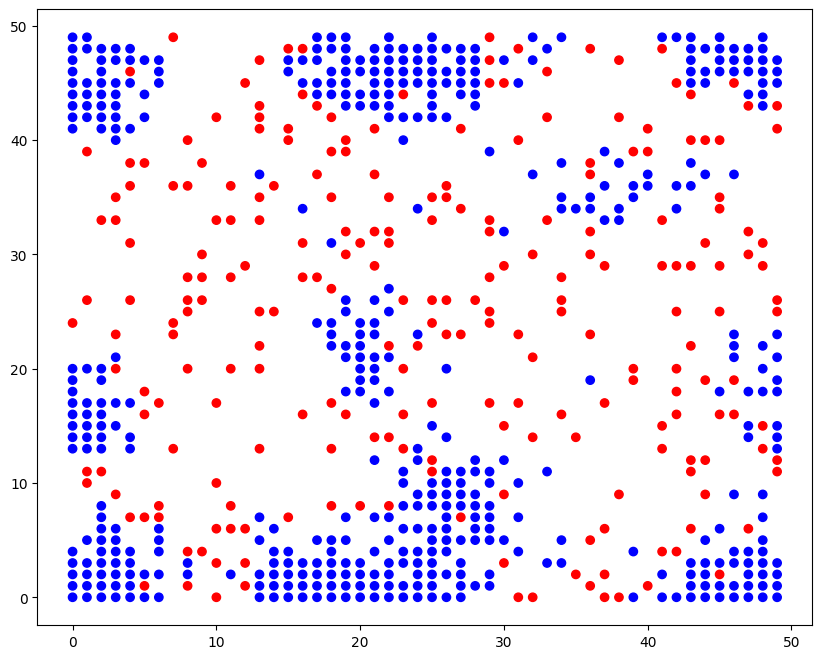

In [16]:
fig, ax = plt.subplots(figsize=(20,10))

env = Environment()         
env.plot()                 

for i in range(20):
    env.timestep()          
    time.sleep(1.0)
    if (i%1==0):
        env.plot()         

&#9989;  **Question 2.6 (5 points)** Now that we have a working model, think about what types of things you could use the model to investigate.  
1. (1 point) In the markdown cell below, ask a question about the system that you might be able to answer with the model.
2. (2 points) Use the code cell to try to answer your question.  If it makes sense with your question, use built-in options of the code if possible.
3. (2 points) Then, qualitatively answer the question you set out to answer in detail.
4. Extra credit (5 points) if you can answer your question quantitatively with some type of graph!

*How does the likelihood of prey production affect the environment's population dynamics?

<Figure size 2000x1000 with 0 Axes>

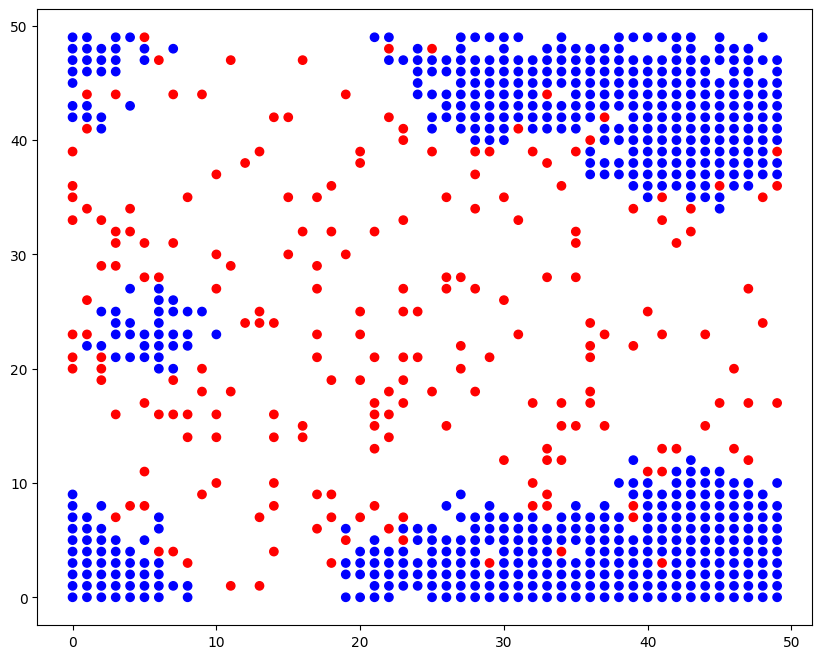

In [18]:
# Use this cell to explore your question
env_low_rep = Environment(reproduce_likelihood=0.1)
env_high_rep = Environment(reproduce_likelihood=0.8)

steps = 30

print("Low reproduction likelihood (0.1):")
for i in range(steps):
    env_low_rep.timestep()
env_low_rep.plot()

print("High reproduction likelihood (0.8):")
for i in range(steps):
    env_high_rep.timestep()
env_high_rep.plot()

*When prey reproduction is low, that leads to fewer predators. Because of this, the environment is going to be less full, and there will be fewer of both predators and prey*

---
### &#128721; STOP 

**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit  and push the changes to your Git repository.



---
[Back to ToC](#toc)
<a id="graph"></a>

# Part 3: Graph theory for sports data (30 points)

In this part of the homework, we will look at a dataset which contains the final score of all NCAA football games between Football Bowl Subdivision (FBS) teams during the 2025 season. We will model this data as a directed graph where each team is a node, and for each game, there is a directed edge from the winning team to the losing team. 

So for example, if we only had four teams (Team A, Team B, Team C, and Team D) and Team A beat Team B, Team A beat Team C, Team B beat Team C, and Team C beat Team D, our directed graph would look like this: 

<img src="https://i.ibb.co/VvKLQYy/Four-Team-Graph.png" width=150px align="center">

However, since there are several FBS teams and several games between them, our directed graph will actually have a lot more nodes and edges. Here's a pretty graph that someone else made with a similar but different dataset. <br>
 <img src="https://blogs.acu.edu/coba/files/2016/12/ncaa-football-diagram-490x376.jpg" width=450px align="center" alt="Image credit: https://blogs.acu.edu/">

For those of you who don't know much about football or even sports in general, don't panic. No intricate sports knowledge is needed.

&#9989;  **Question 3.1 (3 points)**: For convenience, you are provided with a file called `NCAAFootballScores2025.csv`, which you can download from here: 

`https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/refs/heads/main/data/NCAAFootballScores2025.csv` [link](https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/refs/heads/main/data/NCAAFootballScores2025.csv)

Each row contains data from one game between two FBS teams. The first and third columns contain the names of the home team and the away team respectively. The second and fourth columns contain the number of points that the home team and the away team scored respectively. 

**Do This:** Load the data in this file into a `Pandas` `DataFrame`, and **give the columns appropriate titles**.  Print how many games are summarized in this dataset?  And, Display the first few and last few rows of the `DataFrame`. 

In [ ]:
# Put your code for Question 3.1 here and print the number of games in the dataset!

Next, you will construct the directed graph to represent this data.

&#9989;  **Question 3.2 (5 points)**: Create an empty `DiGraph` object from the `networkx` package. For each row of the `DataFrame`, add a directed edge from the node corresponding to the winning team (the one with the larger score) to the node corresponding to the losing team (the one with the smaller score). Note that there are no ties in college football.

Remember that each edge in a directed graph has an orientation. So adding an edge from node A to node B is not the same thing as adding an edge from node B to node A. 

In [ ]:
# Put your code for Question 3.2 here:

This graph has over 100 nodes and hundreds of edges, so it will be hard to look at the entire graph at once. But we can construct and display a small subgraph of the entire directed graph.

&#9989;  **Question 3.3 (7 points)**: The cell below contains a list of all the teams in the Big Ten Conference (yes, there are more than 10 teams in this dictionary) 

**Do the following**: 
* (1 point) Using the `subgraph()` method in the `networkx` package, create another `DiGraph` object which is the subgraph  using the nodes in the `Big_Ten_Teams` list below. In other words, this subgraph should have only the nodes corresponding to the Big Ten teams and only the edges between teams in the Big Ten. 
* (3 points) Then, draw this subgraph where each node is labeled with the team name.  Use an existing method in `networkx` to make the layout of the nodes circular so it is easier to read.
* (3 points) Finally, explicitly set the colors of the nodes, edges, and labels to any color scheme that you like. 

If you do this part correctly, you should get something that looks like this:<br> <img src="https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/refs/heads/main/images/BigTenNetwork.png" width=500px align="center" alt="Image credit: https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/refs/heads/main/images/BigTenNetwork.png">

In [ ]:
# Put your code for Question 3.3 here:
Big_Ten_Teams = ["Illinois","Indiana","Iowa","Maryland","Michigan State",
                 "Michigan","Minnesota","Nebraska","Northwestern",
                 "Ohio State","Oregon","Penn State","Purdue","Rutgers",
                 "UCLA","USC","Washington","Wisconsin"]


&#9989;  **Question 3.4 (6 points total)**: For each part of Question 3.4, use either or both of the `DiGraph` objects you created along with a short amount of networkx code to find answer. **Note that you must use a networkx method to receive credit, and answers based on using the original csv file, the DataFrame, or by simply looking at the plot in Question 3.3 will not receive credit.**

**Question 3.4.1 (1 point)**: What is total number of FBS teams?

**Question 3.4.2 (1 point)**: What is total number of Big Ten teams?

**Question 3.4.3 (1 point)**: How many games did `"Michigan State"` play against Big Ten teams?

**Question 3.4.4 (1 point)**: How many games did `"Wisconsin"` win against FBS teams?

**Question 3.4.5 (1 point)**: How many games did `"Indiana"` lose against Big Ten teams?

**Question 3.4.6 (1 point)**: True or False?: `"Georgia"` lost to `"Alabama"`. Note that these are not Big Ten teams. 

If you get stuck, look through the [`networkx` `DiGraph` documentation](https://networkx.org/documentation/stable/reference/classes/digraph.html) and/or think carefully about how teams and game results are represented in the two `DiGraph` objects. Searching the `networkx` documentation for some of the following terms will be helpful: "nodes", "has edge", "degree", "in degree", "out degree". Also, think carefully about whether you need to use the full graph with all the FBS teams or the subgraph with just the Big Ten teams for each question.

In [ ]:
# Question 3.4.1: What is total number of FBS teams?

In [ ]:
# Question 3.4.2: What is total number of Big Ten teams?

In [ ]:
# Question 3.4.3: How many games did "Michigan State" play against Big Ten teams?

In [ ]:
# Question 3.4.4: How many games did "Wisconsin" win against FBS teams?

In [ ]:
# Question 3.4.5: How many games did "Indiana" lose against Big Ten teams?

In [ ]:
# Question 3.4.6: True or False?: "Georgia" lost to "Alabama". Note that these are not Big Ten teams.

&#9989;  **Question 3.5 (5 points)**: There are over 100 FBS teams, but each team only gets to play a few of the other teams. However, fans still want to be able to argue that their team is better than another team, even if their team didn't play and beat that other team. One way to do this is using the "transitive property". For example, if Team A beat Team B and Team B beat Team C, then Team A's fans can say "Since Team A is better than Team B, and Team B is better than Team C, Team A must be better than Team C." 

This isn't a perfectly logical argument since there is some luck in sports, and so the "better" team doesn't always win. Furthermore, if Team A beats Team B, Team B beats Team C, and Team C beats Team A, then the fanbases of all three teams can argue that their team is better than a team they lost to. Of course, arguments about sports are often not based on logic. :P

We can extend this "transitive property"-based reasoning by using more intermediate teams. In general, if Team $A_0$ beat Team $A_1$, Team $A_1$ beat Team $A_2$, ..., and Team $A_{n-1}$ beat Team $A_n$, then Team $A_0$'s fans can claim that Team $A_0$ is better than Team $A_n$. Obviously, the more intermediate teams you need, the less credible the argument sounds. The website https://www.myteamisbetterthanyourteam.com/ helps fans find a shortest path of comparisons to claim that their team is better than someone else's team. 

**Do this**: Our goal is to make a function that takes in the directed graph that you created along with two strings called `my_team` and `their_team`, and then prints a sequence of statements of the form "[TEAM NAME] beat [TEAM NAME]" which can be used to argue that `my_team` is better than `their team` (assuming such a sequence exists). To do this, the function will first use the `shortest_path()` method to generate a list of teams $[A_0,A_1,\ldots,A_n]$ which forms the shortest path from `my_team` to `their_team`. Then, it will iterate through this list to print out the sequence of statements "Team $A_i$ beat Team $A_{i+1}$".  

*Note:* See the additional discussion below for some hints about what to do here.

In [ ]:
# Put your code for Question 3.5 here:
def find_argument(digraph,my_team,their_team): # Don't change this line
    pass
    

**Do This**: Test out your `find_argument()` method by running the cell below. The first few lines of the output should look something like this:


Michigan State is better than Alabama because ...  
Michigan State beat Central Michigan  
Central Michigan beat South Alabama  
South Alabama beat Oklahoma State  
Oklahoma State beat Oklahoma  
Oklahoma beat Texas  
Texas beat Alabama  


In [ ]:
# Replace the variable "digraph" with whatever you called your DiGraph with all FBS teams
print("Michigan State is better than Ohio State because ...")
find_argument(digraph,"Michigan State","Ohio State")
print("\nMichigan State is better than Minnesota because ...")
find_argument(digraph,"Michigan State","Minnesota")
print("\nEastern Michigan is better than Illinois because ...")
find_argument(digraph,"Eastern Michigan","Illinois")
print("\nIllinois is better than Eastern Michigan because ...")
find_argument(digraph,"Illinois","Eastern Michigan")
# Replace the variable "digraph" with whatever you called your DiGraph with all FBS teams

&#9989;  **Question 3.6 (3 points):** A graph/network is said to have a "[community structure](https://en.wikipedia.org/wiki/Community_structure)" if the nodes can be partitioned into communities such that generally nodes are connected to a high percentage of other nodes in the same community and a low percentage of nodes in other communities. Many real world graphs/networks (particularly those modeling social networks) have a "community structure". By taking a graph and detecting which nodes are part of tightly connected communities, we can often gain valuable insights into our graph. 


Most NCAA Football Bowl Subdivision teams are organized into conferences with 8 to 14 teams per conference. Typically, teams which are part of a conference will play most or all of the other teams in their conference and only a few teams outside their conference. Hence, the graph we generated with all the FBS teams will have this community structure. The pretty graph at the beginning of Part 3 is a good visualization of this structure.

Of course, we can easily look up which teams were in which conferences during the 2025 football season. However, let's see how easily we can detect this from the data. The Louvain method is one algorithm for community detection. If you are curious, you can read the Wikipedia article here https://en.wikipedia.org/wiki/Louvain_method, but it is not required.

**Do This:** First, make an undirected `Graph` that has the same nodes and edges as your `DiGraph` containing all FBS teams. There is a simple `networkx` `DiGraph` method to do this (basically convert the directed graph to an undirected one). Next, use the `louvain_communities()` method which is in the `community` subpackage of `networkx` to partition the graph into communities using the Louvain Community Detection Algorithm. The output of this method is a list of sets where each set represents a community. Finally, print the output of this algorithm.

You may want to read the documentation for the [`louvain_comminities()`](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html) method.

In [ ]:
# Put your code for Question 3.6 here:

&#9989;  **Question 3.7 (2 points):** What teams were detected to be in the same community as `"Michigan State"`? How well does this match up with the teams that are in the Big Ten Conference? Are there any teams included in the same community as `"Michigan State"` that are not part of the Big Ten Conference? Are there any teams in the Big Ten Conference that were not included in the same community as `"Michigan State"`? (See Question 3.3 if you forgot which teams are in the Big Ten Conference). 

**Optional:** Those of you who are either sports fans or interested in community detection may want to look at the other communities that were detected and see how those align with the FBS conferences for the 2025 season. 

**<font size=+3>&#9998;</font> Put your answer here**

---
## &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your Git repository with a useful commit message, and push the changes to your GitHub repository.

---
## Assignment wrap-up



### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the **"Homework Assignments"** folder, find the dropbox link for Homework #2, and upload it there.

&#169; Copyright 2026,  Department of Computational Mathematics, Science and Engineering at Michigan State University